# TSV vs original GODMAX: collisionless-matter mass conservation and HMC audit

**Bottom line.** The TSV central finite-difference derivative is the correct *direction* and sharply improves collisionless-mass closure. The final pipeline $P_{gg}$ ratio returns to unity, but the explicit pre-clip control shows why that is not independent proof: the central raw $u_{\rm clm}$ overshoots one and the existing upper clip sets the first interpolated $k$ bin to exactly one for every tested halo. The derivative itself is pure JAX and works with `jit`, nested `vmap`, and reverse-mode autodiff in the environment tested here. The branch as a whole is **not yet HMC-ready**: a constructor diagnostic converts sampled JAX tracers to Python floats, the package refactor left Stage-31 flat imports broken, and the declared minimum JAX version does not support the coordinate-array form of `jnp.gradient`.

Two claims need qualification. On the current default $n_r=23$ grid, central differences improve collisionless mass closure from roughly 4--11% under-recovery to 0.7--2.7% over-recovery, so the source comment's universal `<2%` statement is too strong. Also, the DMB/halofit ratio is nearly unchanged only at low $k$; it changes materially at nonlinear $k$.

This notebook changes one ingredient at a time. Raw branch-to-branch output is not a causal test because the TSV defaults also change `theta_ej_0`, halo-mass range, radial cutoffs, tSZ behavior, and `split_cga_fftlog`.

## 0. Evidence rules and test questions

The executable cells answer four falsifiable questions:

1. Does replacing the right-sided interpolation-knot derivative by a central difference close the radial mass integral, and does the error converge with $n_r$?
2. With every other input held fixed, does it restore the backreaction/no-backreaction large-scale $P_{gg}$ ratio?
3. Is DMB/halofit genuinely unchanged over the full $k$ range, or only in the large-scale limit?
4. Does the differentiable path survive `jit`, nested `vmap`, and reverse-mode gradients all the way through the TSV constructor used by HMC?

Expected failures are caught and printed so that `Run All` completes. Re-run the notebook before treating any displayed output as evidence.

In [1]:
# Precision must be configured before the first JAX array is created.
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/godmax-mpl')
from jax import config as jax_config
jax_config.update('jax_enable_x64', True)

import copy
import subprocess
import sys
import textwrap
import warnings
from functools import partial
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import yaml

ORIGINAL_ROOT = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX')
TSV_ROOT = Path('/mnt/ceph/users/spandey/ltu-godmax/tsv-godmax/GODMAX')
assert (ORIGINAL_ROOT / 'src/get_radial_profiles.py').exists()
assert (TSV_ROOT / 'src/godmax/get_radial_profiles.py').exists()

def git_value(root, *args):
    return subprocess.check_output(['git', '-C', str(root), *args], text=True).strip()

print('Python:', sys.version.split()[0])
print('JAX/jaxlib:', jax.__version__, jax.lib.__version__)
print('backend/devices:', jax.default_backend(), jax.devices())
print('x64/default dtype:', jax.config.jax_enable_x64, jnp.ones(1).dtype)
print('original:', git_value(ORIGINAL_ROOT, 'rev-parse', '--abbrev-ref', 'HEAD'), git_value(ORIGINAL_ROOT, 'rev-parse', 'HEAD'))
print('TSV:', git_value(TSV_ROOT, 'rev-parse', '--abbrev-ref', 'HEAD'), git_value(TSV_ROOT, 'rev-parse', 'HEAD'))

Python: 3.10.16
JAX/jaxlib: 0.5.0 0.5.0
backend/devices: cpu [CpuDevice(id=0)]
x64/default dtype: True float64
original: ltuSP 29c3a2776ace0f9d2d03a04d39967ff1525ca04b


TSV: tsv-dev-debug b876522a469355b273b847e53b7bd4bc359adb37


## 1. What changed?

The derivative is only one part of a broad branch. The next cell records the source manifest; later tests deliberately use one common configuration and monkeypatch only the derivative. Byte-identical FFTLog core files are a useful null control: `mcfit_jax.py` and `loggamma_jax.py` did not change.

In [2]:
old_src = ORIGINAL_ROOT / 'src'
new_src = TSV_ROOT / 'src/godmax'
diff = subprocess.run(
    ['diff', '-rq', str(old_src), str(new_src)],
    text=True, capture_output=True, check=False
).stdout.splitlines()
interesting = [line for line in diff if not any(x in line for x in ('__pycache__', '/arxiv', '/context', '.DS_Store'))]
print('Source-tree differences (cache/history excluded):')
print('\n'.join(interesting))
for rel in ('mcfitjax/mcfit_jax.py', 'mcfitjax/loggamma_jax.py'):
    same = (old_src / rel).read_bytes() == (new_src / rel).read_bytes()
    print(f'byte-identical null: {rel}: {same}')

Source-tree differences (cache/history excluded):
Only in /mnt/ceph/users/spandey/ltu-godmax/tsv-godmax/GODMAX/src/godmax: __init__.py
Only in /mnt/ceph/users/spandey/ltu-godmax/GODMAX/src: arxiv
Files /mnt/ceph/users/spandey/ltu-godmax/GODMAX/src/base_class.py and /mnt/ceph/users/spandey/ltu-godmax/tsv-godmax/GODMAX/src/godmax/base_class.py differ
Only in /mnt/ceph/users/spandey/ltu-godmax/GODMAX/src: context
Files /mnt/ceph/users/spandey/ltu-godmax/GODMAX/src/get_B12_profile.py and /mnt/ceph/users/spandey/ltu-godmax/tsv-godmax/GODMAX/src/godmax/get_B12_profile.py differ
Files /mnt/ceph/users/spandey/ltu-godmax/GODMAX/src/get_Cls.py and /mnt/ceph/users/spandey/ltu-godmax/tsv-godmax/GODMAX/src/godmax/get_Cls.py differ
Files /mnt/ceph/users/spandey/ltu-godmax/GODMAX/src/get_OWLS_profile.py and /mnt/ceph/users/spandey/ltu-godmax/tsv-godmax/GODMAX/src/godmax/get_OWLS_profile.py differ
Files /mnt/ceph/users/spandey/ltu-godmax/GODMAX/src/get_Pkzs.py and /mnt/ceph/users/spandey/ltu-godmax/ts

In [3]:
# Raw branch comparisons are confounded by changed defaults. Show the important ones explicitly.
old_cfg = yaml.safe_load((ORIGINAL_ROOT / 'param_files/params_default.yaml').read_text())
new_cfg = yaml.safe_load((TSV_ROOT / 'param_files/params_default.yaml').read_text())
default_rows = [
    ('theta_ej_0', old_cfg['sim_params']['theta_ej_0'], new_cfg['sim_params']['theta_ej_0']),
    ('lg10_Mmin', old_cfg['halo_params']['lg10_Mmin'], new_cfg['halo_params']['lg10_Mmin']),
    ('lg10_Mmax', old_cfg['halo_params']['lg10_Mmax'], new_cfg['halo_params']['lg10_Mmax']),
    ('split_cga_fftlog', old_cfg['analysis'].get('split_cga_fftlog', False), new_cfg['analysis'].get('split_cga_fftlog', False)),
    ('baryonification_tSZ', old_cfg['analysis'].get('baryonification_tSZ', '<absent>'), new_cfg['analysis'].get('baryonification_tSZ', '<absent>')),
]
print(f"{'setting':24s} {'original':>12s} {'TSV':>12s}")
for key, old, new in default_rows:
    print(f'{key:24s} {str(old):>12s} {str(new):>12s}')
print('PyYAML nbar value/type (shared problem):', new_cfg['analysis']['nbar_gal_comoving_val'], type(new_cfg['analysis']['nbar_gal_comoving_val'][0]).__name__)

setting                      original          TSV
theta_ej_0                        2.0          1.0
lg10_Mmin                        11.5         10.5
lg10_Mmax                        15.5         16.5
split_cga_fftlog                False         True
baryonification_tSZ          <absent>         True
PyYAML nbar value/type (shared problem): ['5e-4'] str


### Source classification

| Area | TSV change | Audit result |
|---|---|---|
| `get_rho_clm` | interpolation-knot autodiff $\to$ central log difference | Correct target; much better and convergent, but only approximately conservative under trapezoidal reintegration |
| grid/config parsing | proper `[start, stop, n]` expansion; dedicated `num_points_gal_cal` key | Improvements; broad exception fallback should be narrowed |
| radial support | new coverage warning and changed 8/16/6-$r_{200c}$ cutoffs | Warning is physically useful but breaks JAX tracing; cutoffs are separate physics changes |
| satellite stellar mass | extra `ln(10)` in an integral already using $d\ln M$ | Regression; demonstrated below |
| `split_cga_fftlog` | analytic central-galaxy transform, enabled by default | Independent numerical change; validate separately |
| tSZ / $P_{yy}$ | new pressure switch; work moved from covariance to $C_\ell$ object | Independent physics/API/performance change; not validated by the CLM test |
| `get_Cls` stacking | explicit Python stack and LOS axis | Shape intent is clearer, but test degenerate `nz=1` and HMC compile size |
| map projection | removed original `physical_table_cosh` option | Regression: TSV silently falls back to the historical mixed-unit projector |
| package layout | modules moved under `godmax.*` | Package imports work, but many downstream flat imports were not migrated |


## 2. The enclosed-mass derivative

The identity is

$$\rho_{\rm clm}(r)=\frac{1}{4\pi r^2}\frac{dM_{\rm clm}}{dr}=\frac{M_{\rm clm}}{4\pi r^3}\frac{d\ln M_{\rm clm}}{d\ln r}.$$

The original evaluates the derivative of a piecewise-linear interpolant exactly at its knots. JAX selects a one-sided segment slope there. Combining those one-sided slopes with a trapezoidal radial reintegration produces a systematic error when $\ln M(\ln r)$ is curved. A flat outer enclosed-mass tail correctly has zero density; the problem is not that a physically flat tail differentiates to zero.

In [4]:
def source_excerpt(path, first, last):
    lines = Path(path).read_text().splitlines()
    return '\n'.join(f'{i:4d}: {lines[i-1]}' for i in range(first, last + 1))

print('ORIGINAL derivative (src/get_radial_profiles.py:847-868)')
print(source_excerpt(ORIGINAL_ROOT / 'src/get_radial_profiles.py', 847, 868))
print('\nTSV derivative (src/godmax/get_radial_profiles.py:959-982)')
print(source_excerpt(TSV_ROOT / 'src/godmax/get_radial_profiles.py', 959, 982))

ORIGINAL derivative (src/get_radial_profiles.py:847-868)
 847:     def get_rho_clm(self, jz, jM, r_array_here=None):
 848:         '''Get the rho_clm directly following Schneider 2019 paper. Thanks to Sven Heydenreich for identifying bug in original expression.'''
 849:         if r_array_here is None:
 850:             r_array_here = self.r_array
 851:             Mclm_here = self.Mclm_mat[:, jz, jM]
 852:         else:
 853:             Mclm_here = jnp.exp(jnp.interp(jnp.log(r_array_here), jnp.log(self.r_array), jnp.log(self.Mclm_mat[:, jz, jM])))
 854:         
 855:         # lnMclm_interp = interpax.CubicSpline(jnp.log(r_array_here), jnp.log(jnp.clip(Mclm_here, 0, None) + 1e-30), extrapolate=True, check=False)
 856:         # lnMclm_interp = interpax.Akima1DInterpolator(jnp.log(r_array_here), jnp.log(Mclm_here + 1e-30), extrapolate=True, check=False)
 857:         # lnMclm_interp = interpax.PchipInterpolator(jnp.log(r_array_here), jnp.nan_to_num(jnp.log(jnp.clip(Mclm_here, 0, None

In [5]:
# Pure versions of the two operators. These are used for controlled tests below.
def rho_original(r, enclosed_mass):
    x = jnp.log(r)
    y = jnp.log(jnp.clip(enclosed_mass, 0.0) + 1e-30)
    slope = jax.vmap(jax.grad(lambda q: jnp.interp(q, x, y)))(x)
    return jnp.clip(slope * enclosed_mass / (4.0 * jnp.pi * r**3), 0.0, 1e30)

def rho_tsv(r, enclosed_mass):
    x = jnp.log(r)
    y = jnp.log(jnp.clip(enclosed_mass, 0.0) + 1e-30)
    slope = jnp.gradient(y, x)
    return jnp.clip(slope * enclosed_mass / (4.0 * jnp.pi * r**3), 0.0, 1e30)

def recovered_delta_mass(r, rho):
    return jnp.trapezoid(4.0 * jnp.pi * r**2 * rho, x=r)

# Knot behavior on y=x^2: original is the right-segment slope at interior knots.
x = jnp.arange(5.0)
y = x**2
right_knot = jax.vmap(jax.grad(lambda q: jnp.interp(q, x, y)))(x)
central = jnp.gradient(y, x)
print('right-knot slopes:', right_knot)
print('central slopes:   ', central)

right-knot slopes: [1. 3. 5. 7. 7.]
central slopes:    [1. 2. 4. 6. 7.]


### Null control: an exact power law

For $M=A r^p$, $\ln M$ is linear in $\ln r$. Both operators should be exact. This control distinguishes the knot/quadrature interaction from a generic failure of autodiff or logarithmic differentiation.

In [6]:
r = jnp.geomspace(5e-4, 16.0, 128)
A, p = 3.7, 1.6
M_power = A * r**p
rho_exact = A * p * r**(p - 3.0) / (4.0 * jnp.pi)
err_old = jnp.max(jnp.abs(rho_original(r, M_power) / rho_exact - 1.0))
err_new = jnp.max(jnp.abs(rho_tsv(r, M_power) / rho_exact - 1.0))
print('max relative density error, original/TSV:', float(err_old), float(err_new))
assert float(err_old) < 1e-10 and float(err_new) < 1e-10

max relative density error, original/TSV: 9.325873406851315e-15 9.547918011776346e-15


### Curved/saturating profile: grid convergence

This synthetic cumulative profile is smooth, monotonic, and saturating. The correct recovered shell mass is $M(r_{\max})-M(r_{\min})$. The central operator should converge rapidly toward unity; exact conservation is not guaranteed because the derivative and downstream trapezoid are not a matched finite-volume pair.

   nr       original    TSV central
   23     0.92852367     1.04241377
   32     0.94174670     1.02122817
   64     0.96651120     1.00511509
  128     0.98216683     1.00125727
  256     0.99081100     1.00031178


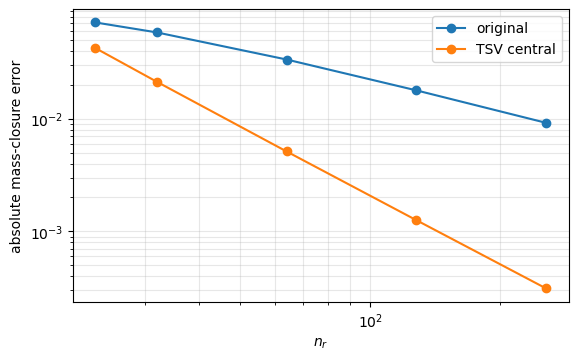

In [7]:
def saturating_mass(r, scale=0.6):
    return 2.4e14 * (1.0 - jnp.exp(-(r / scale)**0.72)) + 1e4

rows = []
for nr in (23, 32, 64, 128, 256):
    rr = jnp.geomspace(5e-4, 16.0, nr)
    mm = saturating_mass(rr)
    target = mm[-1] - mm[0]
    old_ratio = recovered_delta_mass(rr, rho_original(rr, mm)) / target
    new_ratio = recovered_delta_mass(rr, rho_tsv(rr, mm)) / target
    rows.append((nr, float(old_ratio), float(new_ratio)))
print(f"{'nr':>5s} {'original':>14s} {'TSV central':>14s}")
for nr, old_ratio, new_ratio in rows:
    print(f'{nr:5d} {old_ratio:14.8f} {new_ratio:14.8f}')

fig, ax = plt.subplots(figsize=(6.4, 3.8))
nrs = np.array([q[0] for q in rows])
ax.loglog(nrs, np.abs(np.array([q[1] for q in rows]) - 1), 'o-', label='original')
ax.loglog(nrs, np.abs(np.array([q[2] for q in rows]) - 1), 'o-', label='TSV central')
ax.set(xlabel='$n_r$', ylabel='absolute mass-closure error')
ax.grid(True, which='both', alpha=.3); ax.legend(); plt.show()
assert abs(rows[-1][2] - 1) < abs(rows[-1][1] - 1)

### Actual TSV $M_{\rm clm}$ on its default grid

This uses the *same enclosed-mass tensor* for both derivatives, so other source differences cannot explain the result. The only input repair is converting the shared YAML value `[5e-4]`, which PyYAML reads as a string list, to the intended scalar `5.0e-4`. The denominator is the mass represented between the radial endpoints, not the total halo mass outside the grid.

In [8]:
# Add both source roots without relying on the broken legacy TSV import contract.
sys.path.insert(0, str(TSV_ROOT / 'src'))
from godmax.get_radial_profiles import Profiles as TSVProfiles

cfg = yaml.safe_load((TSV_ROOT / 'param_files/params_default.yaml').read_text())
sim = copy.deepcopy(cfg['sim_params'])
halo = copy.deepcopy(cfg['halo_params'])
analysis = copy.deepcopy(cfg['analysis'])
other = copy.deepcopy(cfg['other_params'])
analysis.update(model_tSZ=False, model_galaxies=True, backreaction=True,
                nbar_gal_comoving_val=5.0e-4, verbose_time=False,
                symbolic_hmf=True, symbolic_pk=True)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    profile_default = TSVProfiles(sim, halo, analysis, other)
print('grid (nr,nz,nM):', profile_default.nr, profile_default.nz, profile_default.nM)
print('mass range:', float(profile_default.M_array[0]), float(profile_default.M_array[-1]))
print('coverage warnings:', [str(w.message) for w in caught])

r_default = profile_default.r_array
M_default = profile_default.Mclm_mat
M_rows = M_default.reshape((profile_default.nr, -1))
rho_old = jax.vmap(lambda m: rho_original(r_default, m), in_axes=1, out_axes=1)(M_rows).reshape(M_default.shape)
rho_new = profile_default.rho_clm_mat
pref = 4.0 * jnp.pi * r_default[:, None, None]**2
delta = M_default[-1] - M_default[0]
closure_old = jnp.trapezoid(pref * rho_old, x=r_default, axis=0) / delta
closure_new = jnp.trapezoid(pref * rho_new, x=r_default, axis=0) / delta
for label, value in [('original operator', closure_old), ('TSV central', closure_new)]:
    print(label, 'min/median/max/max|err| =', *(float(x) for x in
          (value.min(), jnp.median(value), value.max(), jnp.max(jnp.abs(value - 1.0)))))
print('negative Mclm steps / clipped-zero central rho nodes:',
      int(jnp.sum(jnp.diff(M_default, axis=0) < 0)), int(jnp.sum(rho_new == 0)))

grid (nr,nz,nM): 23 22 24
mass range: 31622776601.683792 3.162277660168379e+16
coverage warnings: ["FFTLog grid under-covers the halo profiles: rmax (r_array[-1]) = 8 Mpc < max profile extent 29.2 Mpc (rt_max = 29.2, r_ej_max = 7.3). Massive/extended haloes are truncated on the grid, so _profile_grid_mass < Mtot and u(k) is distorted for them. Increase halo_params['rmax'] to >~ 29.2 Mpc."]


original operator min/median/max/max|err| = 0.8889752343197653 0.8949449669439608 0.9583644202989144 0.11102476568023467
TSV central min/median/max/max|err| = 1.007331854857365 1.0261883827522507 1.0269403358375992 0.02694033583759925
negative Mclm steps / clipped-zero central rho nodes: 14 16


**Interpretation.** Central differences are decisively better, but `jnp.gradient` plus a separate trapezoid is not exactly conservative. At default resolution the worst case is above 2%, and a small number of non-monotonic $M_{\rm clm}$ steps are clipped in density. For strict conservation, use a finite-volume shell construction whose shell masses telescope to the endpoint difference, or explicitly normalize only after checking that the correction converges and does not hide negative shells.

## 3. Causal power-spectrum test

The next cell stays entirely within the TSV branch and monkeypatches only `Profiles.get_rho_clm`. It builds a shared no-backreaction reference, then old-derivative and central-derivative backreaction models with identical parameters. $r_{\max}=48$ Mpc/h avoids the known profile-support warning for this reduced test.

The primary large-scale statistic is $P_{gg}^{2h,\,back}/P_{gg}^{2h,\,no\ back}$. The null is the *change caused by the derivative* in $(P_{mm}^{DMB}/P_{mm}^{halofit})$. We report it separately for $k\le10^{-2}$ and all $k$; an all-$k$ null was not physically expected because CLM is part of DMB.

low-k max |Pgg2h(back/no-back)-1|, old: 0.07110798470834234
low-k max |Pgg2h(back/no-back)-1|, central: 2.1750528198305474e-05
derivative change in DMB/halofit, max |ratio-1| low-k: 0.005116658675442198
derivative change in DMB/halofit, max |ratio-1| all-k: 0.23250950128556347
no-backreaction null max |old-central| rho_clm/Pgg2h/Pmm: 0.0 0.0 0.0
old raw FFTLog u_clm first-k min/median/max: 0.8412057304756988 0.8626991780761943 1.2017512146087963
old interpolated/clipped u_clm first-k min/median/max: 0.8412057304756988 0.8626991780761943 1.0
central raw FFTLog u_clm first-k min/median/max: 1.0109080382856301 1.0197303188023632 1.3261730914098984
central interpolated/clipped u_clm first-k min/median/max: 1.0 1.0 1.0


nr=47 low-k Pgg2h max deviation, old/central: 0.036293717326213115 8.256157003683207e-05
nr=47 DMB/halofit derivative change, low/all-k: 0.0002771133346813892 0.1069552365120292


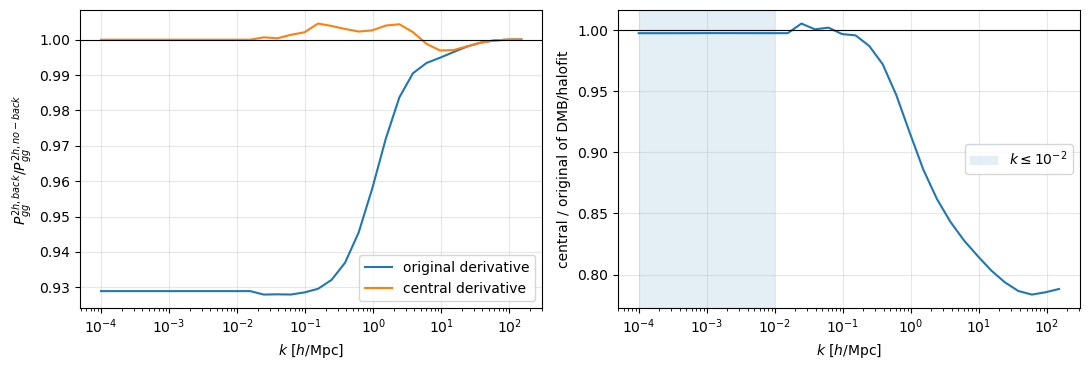

In [9]:
import godmax.get_radial_profiles as tsv_radial
from godmax.get_Pkzs import get_Pkz as TSVPk

cfg = yaml.safe_load((TSV_ROOT / 'param_files/params_default.yaml').read_text())
pk_sim = copy.deepcopy(cfg['sim_params'])
pk_halo = copy.deepcopy(cfg['halo_params'])
pk_analysis = copy.deepcopy(cfg['analysis'])
pk_other = copy.deepcopy(cfg['other_params'])
pk_halo.update(nz=2, nM=6, nr=23, nk=32, lg10_Mmin=10.5, lg10_Mmax=16.5,
               rmin=0.005, rmax=48.0)
pk_analysis.update(model_tSZ=True, model_galaxies=True, verbose_time=False,
                   nbar_gal_comoving_val=5.0e-4, split_cga_fftlog=False,
                   symbolic_hmf=True, symbolic_pk=True, baryonification_tSZ=True)

def build_pk(backreaction):
    a = copy.deepcopy(pk_analysis)
    a['backreaction'] = backreaction
    return TSVPk(copy.deepcopy(pk_sim), copy.deepcopy(pk_halo), a, copy.deepcopy(pk_other))

central_method = tsv_radial.Profiles.get_rho_clm
@partial(jax.jit, static_argnums=(0,))
def old_method(self, jz, jM, r_array_here=None):
    if r_array_here is None:
        r_here = self.r_array
        M_here = self.Mclm_mat[:, jz, jM]
    else:
        r_here = r_array_here
        M_here = jnp.exp(jnp.interp(jnp.log(r_here), jnp.log(self.r_array),
                                     jnp.log(self.Mclm_mat[:, jz, jM])))
    x = jnp.log(r_here)
    y = jnp.log(jnp.clip(M_here, 0.0) + 1e-30)
    slope = jax.vmap(jax.grad(lambda q: jnp.interp(q, x, y)))(x)
    return jnp.clip(slope * M_here / (4.0 * jnp.pi * r_here**3), 0.0, 1e30)

def matched_four(nr):
    pk_halo['nr'] = nr
    try:
        tsv_radial.Profiles.get_rho_clm = central_method
        no_back = build_pk(False)
        tsv_radial.Profiles.get_rho_clm = old_method
        no_back_old = build_pk(False)
        old = build_pk(True)
        tsv_radial.Profiles.get_rho_clm = central_method
        new = build_pk(True)
        return no_back, no_back_old, old, new
    finally:
        tsv_radial.Profiles.get_rho_clm = central_method

p_no, p_no_old, p_old, p_new = matched_four(23)

k = np.asarray(p_new.kPk_array)
low = k <= 1e-2
old_pgg2 = np.asarray(p_old.Pgg_2h_kz_mat / p_no.Pgg_2h_kz_mat)
new_pgg2 = np.asarray(p_new.Pgg_2h_kz_mat / p_no.Pgg_2h_kz_mat)
dmb_null = np.asarray((p_new.Pmm_tot_mat / p_new.phfit_kz_mat) /
                      (p_old.Pmm_tot_mat / p_old.phfit_kz_mat))
maxdev = lambda x: float(np.max(np.abs(x - 1.0)))
print('low-k max |Pgg2h(back/no-back)-1|, old:', maxdev(old_pgg2[low]))
print('low-k max |Pgg2h(back/no-back)-1|, central:', maxdev(new_pgg2[low]))
print('derivative change in DMB/halofit, max |ratio-1| low-k:', maxdev(dmb_null[low]))
print('derivative change in DMB/halofit, max |ratio-1| all-k:', maxdev(dmb_null))
print('no-backreaction null max |old-central| rho_clm/Pgg2h/Pmm:',
      float(jnp.max(jnp.abs(p_no_old.rho_clm_mat - p_no.rho_clm_mat))),
      float(jnp.max(jnp.abs(p_no_old.Pgg_2h_kz_mat - p_no.Pgg_2h_kz_mat))),
      float(jnp.max(jnp.abs(p_no_old.Pmm_tot_mat - p_no.Pmm_tot_mat))))
for label, obj in [('old', p_old), ('central', p_new)]:
    raw = np.asarray(obj.uk_clm_tointp[0])
    clipped = np.asarray(obj.uk_clm[0])
    print(label, 'raw FFTLog u_clm first-k min/median/max:', float(raw.min()), float(np.median(raw)), float(raw.max()))
    print(label, 'interpolated/clipped u_clm first-k min/median/max:', float(clipped.min()), float(np.median(clipped)), float(clipped.max()))

q_no, q_no_old, q_old, q_new = matched_four(47)
k47 = np.asarray(q_new.kPk_array); low47 = k47 <= 1e-2
old47 = np.asarray(q_old.Pgg_2h_kz_mat / q_no.Pgg_2h_kz_mat)
new47 = np.asarray(q_new.Pgg_2h_kz_mat / q_no.Pgg_2h_kz_mat)
null47 = np.asarray((q_new.Pmm_tot_mat / q_new.phfit_kz_mat) /
                    (q_old.Pmm_tot_mat / q_old.phfit_kz_mat))
print('nr=47 low-k Pgg2h max deviation, old/central:', maxdev(old47[low47]), maxdev(new47[low47]))
print('nr=47 DMB/halofit derivative change, low/all-k:', maxdev(null47[low47]), maxdev(null47))
pk_halo['nr'] = 23

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].semilogx(k, old_pgg2[:, 0], label='original derivative')
axes[0].semilogx(k, new_pgg2[:, 0], label='central derivative')
axes[0].axhline(1, color='k', lw=.8); axes[0].set(xlabel='$k$ [$h$/Mpc]', ylabel='$P_{gg}^{2h,back}/P_{gg}^{2h,no-back}$')
axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].semilogx(k, dmb_null[:, 0])
axes[1].axhline(1, color='k', lw=.8); axes[1].axvspan(k.min(), 1e-2, alpha=.12, label='$k\leq10^{-2}$')
axes[1].set(xlabel='$k$ [$h$/Mpc]', ylabel='central / original of DMB/halofit')
axes[1].legend(); axes[1].grid(alpha=.3); plt.tight_layout(); plt.show()

**Interpretation.** The final large-scale $P_{gg}$ ratio does return to unity, but the raw control refutes using that result as independent validation of the derivative. At $n_r=23$ the central raw first-bin $u_{\rm clm}$ is above one for every tested halo (median 1.020; maximum 1.326), after which the existing $u_{\rm clm}\le1$ clip makes the interpolated first bin exactly one. The central derivative still improves direct shell-mass closure, but production validation should require raw $u_{\rm clm}(k\to0)$ near unity without this upper clip. The exact no-backreaction null is zero for density, $P_{gg}^{2h}$, and $P_{mm}$. The DMB/halofit statement must be restricted to an approximate low-$k$ null; nonlinear scales respond because collisionless matter is part of the DMB profile.

## 4. Is the derivative JAX/GPU/HMC compatible?

The operator itself should pass compilation, nested halo/redshift batching, and reverse-mode differentiation. This host has no GPU, so the test proves XLA/JAX structure on CPU—not actual GPU runtime, memory use, or throughput.

In [10]:
r_jax = jnp.geomspace(5e-4, 16.0, 128)
scales = jnp.linspace(0.35, 1.1, 20).reshape(4, 5)

def one_density(scale):
    return rho_tsv(r_jax, saturating_mass(r_jax, scale))

batched = jax.jit(jax.vmap(jax.vmap(one_density)))(scales)
def objective(s):
    weights = jnp.linspace(0.2, 1.0, r_jax.size)
    return jnp.sum(jnp.log1p(one_density(s)) * weights) / r_jax.size

s0 = jnp.array(0.6)
g_ad = jax.grad(objective)(s0)
eps = 1e-5
g_fd = (objective(s0 + eps) - objective(s0 - eps)) / (2 * eps)
batch_grads = jax.jit(jax.vmap(jax.vmap(jax.grad(objective))))(scales)
lowered = jax.jit(one_density).lower(s0)
hlo = lowered.compiler_ir(dialect='hlo').as_hlo_text().lower()
print('nested vmap input/output:', scales.shape, batched.shape)
print('all density/grad finite:', bool(jnp.all(jnp.isfinite(batched))), bool(jnp.all(jnp.isfinite(batch_grads))))
print('reverse grad / parameter finite difference / relative error:',
      float(g_ad), float(g_fd), float(jnp.abs((g_ad-g_fd)/g_fd)))
print('HLO mentions host callback:', 'host_callback' in hlo or 'outside_compilation' in hlo)
assert batched.shape == (4, 5, 128)
assert bool(jnp.all(jnp.isfinite(batch_grads)))


nested vmap input/output: (4, 5) (4, 5, 128)
all density/grad finite: True True
reverse grad / parameter finite difference / relative error: 0.8341431637252007 0.8341431213310101 5.082364107352779e-08
HLO mentions host callback: False


### Compatibility floor

This run uses JAX 0.5.0. TSV declares `jax>=0.4.25`, but JAX 0.4.28 raises `NotImplementedError: Non-constant spacing not implemented` for `jnp.gradient(y, coordinate_array)`. Because `r_array` is log-spaced, the portable form is `jnp.gradient(ln_Mclm, ln_r[1]-ln_r[0])`, together with an assertion that the log spacing is uniform; otherwise implement explicit nonuniform three-point differences. Alternatively raise the declared minimum JAX version. This is a version-contract failure, not a GPU-vectorization failure.

### End-to-end trace blocker in `Profiles.setup_main_calc`

The new grid-coverage warning executes `float(jnp.max(self.r_ej_mat))`, Python `max`, and a Python `if` inside construction. `theta_ej_0` and its mass/redshift exponents are sampled in the Stage-31 prior, so these values are tracers during HMC. The minimal function below reproduces the exact failure pattern.

In [11]:
print(source_excerpt(TSV_ROOT / 'src/godmax/get_radial_profiles.py', 183, 203))

def coverage_diagnostic_pattern(theta_ej):
    r_array = jnp.geomspace(0.005, 8.0, 23)
    r200c = jnp.array([[1.0, 2.0]])
    rt = 4.0 * r200c
    r_ej = theta_ej * r200c
    rmax_grid = float(r_array[-1])
    rt_max = float(jnp.max(rt))
    rej_max = float(jnp.max(r_ej))  # TSV line 190
    return max(rt_max, rej_max) - rmax_grid

print('eager diagnostic:', coverage_diagnostic_pattern(3.0))
for transform in (jax.jit, jax.grad):
    try:
        transform(coverage_diagnostic_pattern)(jnp.array(3.0))
        print(transform.__name__, 'unexpectedly passed')
    except Exception as exc:
        print(transform.__name__, 'expected failure:', type(exc).__name__, str(exc).splitlines()[0])

 183:         # M3 grid-coverage check: the FFTLog grid only reaches rmax = r_array[-1], but the
 184:         # profiles physically extend to the truncation radius rt = epsilon_rt * r200c (and the
 185:         # gas out to ~theta_ej * r200c). If rmax < these for the heaviest/most-extended haloes,
 186:         # the grid truncates the profile inside its own support, so _profile_grid_mass < Mtot
 187:         # and the FFTLog u(k) shape is distorted for those haloes. Warn (does not change results).
 188:         rmax_grid = float(self.r_array[-1])
 189:         rt_max = float(jnp.max(self.rt_mat))
 190:         rej_max = float(jnp.max(self.r_ej_mat))
 191:         # The tSZ pressure (get_Ptot / get_Ptot_nfw) is integrated out to 6*r200c, so the y3d
 192:         # profile needs the grid to reach at least there for Y3D not to be truncated.
 193:         rpress_max = 6.0 * float(jnp.max(self.r200c_mat)) if self.model_tSZ else 0.0
 194:         r_needed = max(rt_max, rej_max, rpress_max)

grad expected failure: ConcretizationTypeError Abstract tracer value encountered where concrete value is expected: traced array with shape float64[]


**Required fix.** Move coverage diagnostics outside the traced model construction. Validate the worst prior corners in a concrete preflight before sampling; do not convert dynamic values to Python scalars in the likelihood path. After that change, run NumPyro `initialize_model(validate_grad=True)` and finite-gradient tests at the fiducial point, best fit, and all prior corners.

### Package/import and precision contracts

The source was moved under `godmax`, but Stage-31 still imports `base_class`, `get_Cls`, `get_Pkzs`, and `get_radial_profiles` as flat modules after adding only `TSV_ROOT/src`. Package import succeeds; the caller's legacy import fails. The Stage-31 entry enables x64 before its JAX imports, which is good, but the library itself also changes global x64 state during `godmax.mcfitjax` import. Entry points should own precision configuration and call both `jax.config.update(..., True)` and `numpyro.enable_x64()` before arrays exist.

In [12]:
env = dict(os.environ)
env['PYTHONPATH'] = str(TSV_ROOT / 'src')
def fresh_import(code):
    p = subprocess.run([sys.executable, '-c', code], cwd='/tmp', env=env, text=True, capture_output=True)
    return p.returncode, (p.stdout + p.stderr).strip().splitlines()[-1]

for label, code in [
    ('package', 'import godmax; print("import godmax: PASS")'),
    ('legacy', 'from base_class import base_class; print("flat import: PASS")'),
]:
    print(label, fresh_import(code))
print('Stage-31 stale imports:')
print(source_excerpt(TSV_ROOT / 'notebooks/xDESI/survey_measure/godmax_multiprobe_hmc_stage31.py', 948, 959))

package (0, 'import godmax: PASS')
legacy (1, "ModuleNotFoundError: No module named 'base_class'")
Stage-31 stale imports:
 948: def build_one_model_from_config(config: Mapping[str, object], *, is_cmb_lensing: bool):
 949:     gmt.ensure_godmax_import_paths(Path(config["repo_root"]))
 950:     from base_class import base_class
 951:     from get_Cls import get_Cl
 952:     from get_Pkzs import get_Pkz
 953:     from get_radial_profiles import Profiles
 954: 
 955:     sim_params, halo_params, analysis, other_params = _params_for_one_model(config, is_cmb_lensing=is_cmb_lensing)
 956:     base = base_class(sim_params, halo_params, analysis, other_params)
 957:     profiles = Profiles(sim_params, halo_params, analysis, other_params, base_class_obj=base)
 958:     pkz = get_Pkz(sim_params, halo_params, analysis, other_params, Profiles_obj=profiles)
 959:     return get_Cl(sim_params, halo_params, analysis, other_params, Pkz_obj=pkz)


## 5. A separate satellite-stellar-mass regression

The TSV branch multiplies `trapezoid(Nsat*Mstar, x=log(Mstar))` by `ln(10)`. That factor belongs only when the integration coordinate is $\log_{10}M$; it double-counts the Jacobian when `x` is already $\ln M`. This alters the satellite fraction, gas fraction, collisionless fraction, and therefore can confound a branch-level mass or power comparison.

In [13]:
print('original:')
print(source_excerpt(ORIGINAL_ROOT / 'src/get_radial_profiles.py', 742, 746))
print('\nTSV:')
print(source_excerpt(TSV_ROOT / 'src/godmax/get_radial_profiles.py', 854, 858))

Mstar = jnp.geomspace(1e9, 1e13, 4096)
Nsat = (Mstar / 1e10)**-0.35
integral_ln = jnp.trapezoid(Nsat * Mstar, x=jnp.log(Mstar))
integral_log10 = jnp.log(10.0) * jnp.trapezoid(Nsat * Mstar, x=jnp.log10(Mstar))
tsv_expression = jnp.log(10.0) * integral_ln
print('correct dlnM / correct converted dlog10M:', float(integral_ln / integral_log10))
print('TSV expression / correct:', float(tsv_expression / integral_ln))
assert np.isclose(float(tsv_expression / integral_ln), np.log(10.0))

original:
 742:         val1 = (Nsat_mat[0,0,-1]*Mthresh_array[-1] - Nsat_mat[0,0,0]*Mthresh_array[0])
 743:         val2 = jsi.trapezoid(Nsat_mat[0,0,:]*Mthresh_array, x=jnp.log(Mthresh_array))
 744:         Mstar_sat = val2 - val1
 745:         Mtot = self.Mtot_mat[jz, jM]
 746:         result = jnp.clip(Mstar_sat / Mtot, 0, 0.49*self.Ob0/self.Om0)  # Cap at cosmic baryon fraction

TSV:
 854:         val1 = (Nsat_mat[0,0,-1]*Mthresh_array[-1] - Nsat_mat[0,0,0]*Mthresh_array[0])
 855:         val2 = jnp.log(10) * jsi.trapezoid(Nsat_mat[0,0,:]*Mthresh_array, x=jnp.log(Mthresh_array))
 856:         Mstar_sat = val2 - val1
 857:         Mtot = self.Mtot_mat[jz, jM]
 858:         result = jnp.clip(Mstar_sat / Mtot, 0, 0.49*self.Ob0/self.Om0)  # Cap at cosmic baryon fraction


correct dlnM / correct converted dlog10M: 1.0000000000000004
TSV expression / correct: 2.302585092994046


## 6. Final audit matrix

| Claim / invariant | Result | Why |
|---|---|---|
| Central derivative targets the original CLM mass-loss mechanism | **PASS** | It replaces right-sided knot slopes, sharply improves closure, and converges with $n_r$ |
| Exact/default-grid mass conservation | **PARTIAL** | Default worst case is about 2.7% over-recovery; derivative and trapezoid are not a conservative pair |
| Large-scale $P_{gg}$ ratio returns to one | **PIPELINE PASS; PHYSICAL PROOF CONFOUNDED** | Raw central $u_{\rm clm}>1$ is clipped to one before the final ratio |
| DMB/halofit is unaffected | **NEAR-NULL at low $k$; FAIL all-$k$** | The low-$k$ effect converges smaller, but nonlinear DMB contains CLM and changes materially |
| Derivative `jit` / `vmap` / reverse-mode | **PASS on JAX 0.5 CPU** | Nested batches and finite gradients pass; HLO has no host callback |
| GPU runtime | **NOT TESTED** | No GPU is available on this host; structural XLA compatibility is not a runtime benchmark |
| `INV-JAX-TRACE-01` for the TSV branch | **FAIL** | Python float/max/if in the sampled constructor path |
| Stage-31 import contract | **FAIL** | Package refactor did not migrate the flat imports |
| Declared JAX version range | **FAIL** | coordinate-array `jnp.gradient` is unsupported on an allowed JAX 0.4.28 installation |
| Other TSV physics/API changes | **NOT ESTABLISHED here** | tSZ/HSE, split-CGA, $C_\ell$ stacking, and map projection require their own tests |

### Before launching HMC

1. Move the radial-coverage warning to a concrete preflight and remove all tracer-to-Python conversions from constructors.
2. Migrate Stage-31 and theory utilities to `from godmax...` imports (or provide deliberate compatibility shims).
3. Use scalar $\Delta\ln r$ in `jnp.gradient` or raise the minimum JAX version.
4. Remove the extra satellite-integral `ln(10)` and port the original unit-consistent map projector.
5. Promote the notebook's raw pre-clip $u_{\rm clm}(0)$ and no-backreaction controls to tests, diagnostically bypass the upper clip, and add shell-mass closure plus $n_r/r_{min}/r_{max}$ sweeps. Consider a telescoping finite-volume reconstruction if exact conservation is required.
6. Explicitly enable JAX and NumPyro x64 in every inference entry before arrays are created.
7. Only then run `initialize_model(validate_grad=True)`, fiducial/best-fit/prior-corner gradient tests, one real GPU compile, and a short NUTS smoke chain with divergence/tree-depth diagnostics.